In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table
import seaborn as sns

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [2]:
def quality_cuts(df):
        """
        Make quality cuts on the APOGEE catalog.
        Parameters
        ----------
        df : pandas.DataFrame

            Full APOGEE catalog
        Returns
        -------
        pandas.DataFrame
        """
        # Limit to main red star sample
        df = df[df['EXTRATARG'] == 0]

        # Weed out bad flags
        fatal_flags = (2**23) # STAR_BAD
        df = df[df['ASPCAPFLAG'] & fatal_flags == 0]
        # Cut low-S/N targets
        df = df[df['SNREV'] > 200]
        # Limit to giants
        df = df[(df['LOGG'] > 1) & (df['LOGG'] < 2) &
                (df['TEFF'] > 3700) & (df['TEFF'] < 4600)]
        # Replace NaN stand-in values with NaN
        df.replace(99.999, np.nan, inplace=True)
        # Limit to stars with measurements of both [Fe/H] and [O/Fe]
        df.dropna(subset=['FE_H', 'O_FE'], inplace=True)
        df.reset_index(inplace=True, drop=True)
        return df

def fits_to_pandas(path, **kwargs):
    """
    Import a table in the form of a FITS file and convert it to a pandas DataFrame.
    Parameters
    ----------
    path : Path or str
    Path to fits file
    Other keyword arguments are passed to astropy.table.Table
    Returns
    -------
    df : pandas DataFrame
    """
    # Read FITS file into astropy table
    table = Table.read(path, format='fits', **kwargs)
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    # Convert byte-strings to ordinary strings and convert to pandas
    df = decode(table[cols].to_pandas())
    return df

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    Parameters
    ----------
    df : pandas DataFrame
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

In [4]:
from astropy.io import fits
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

In [9]:
twoprocess_df = fits_to_pandas("../../data/astroNN_2proc_crossmatch.fits", hdu=2)
astronn_df = fits_to_pandas("../../data/astroNN_2proc_crossmatch.fits", hdu=1)
adrian_df = fits_to_pandas("../../data/allStar-dr17-synspec_rev1-GaiaDR3-EDR3_STARHORSE_v2-MilkyWayPotential2022-staeckel.fits")
astronn_df['MG_FE'] = astronn_df['MG_H'] - astronn_df['FE_H']
twoprocess_df['A_CC/A_IA'] = twoprocess_df['A_CC']/twoprocess_df['A_IA']
twoprocess_df = twoprocess_df[twoprocess_df['A_CC/A_IA'] > 0]
#twoprocess_df = twoprocess_df[twoprocess_df['A_CC/A_IA'] < 10]

data = (
    adrian_df
    .merge(twoprocess_df, on="APOGEE_ID", how="inner")
    .merge(astronn_df, on="APOGEE_ID", how="inner")
)

data = data.dropna()

#data['A_CC/A_IA'] = data['A_CC']/data['A_IA']
data['A_IA/A_CC'] = data['A_IA']/data['A_CC']
data['MG_FE'] = data['MG_H'] - data['FE_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "red"
data_low_alpha['color'] = "blue"

merged = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

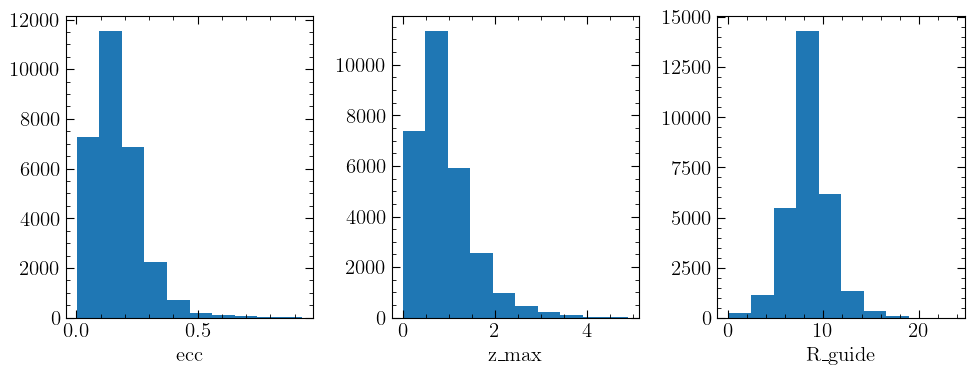

In [10]:
plt.figure(figsize=(10,4))

merged = merged[merged['z_max'] < 5]

plt.subplot(1,3,1)
plt.hist(merged['ecc'])
plt.xlabel('ecc')
mean_ecc = np.mean(merged['ecc'])
std_ecc = np.std(merged['ecc'])



plt.subplot(1,3,2)
plt.hist(merged['z_max'])
plt.xlabel("z_max")
mean_zmax = np.mean(merged['z_max'])
std_zmax = np.std(merged['z_max'])


plt.subplot(1,3,3)
plt.hist(merged['R_guide'])
plt.xlabel("R_guide")
mean_rguide = np.mean(merged['R_guide'])
std_rguide = np.std(merged['R_guide'])



plt.tight_layout()

In [13]:
bin_edges = np.arange(0, 12, 1)  # 0,1,2,...,10

merged['R_guide_bin'] = pd.cut(merged['R_guide'], bins=bin_edges, right=False, labels=False)

In [44]:
bin_edges

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [46]:
circ_ones = merged[merged['ecc'] < 0.2]
binned_dfs = []
for i in bin_edges:
    binned_dfs.append(circ_ones[circ_ones['R_guide_bin'] == i])

In [47]:
bin_test = binned_dfs[0]

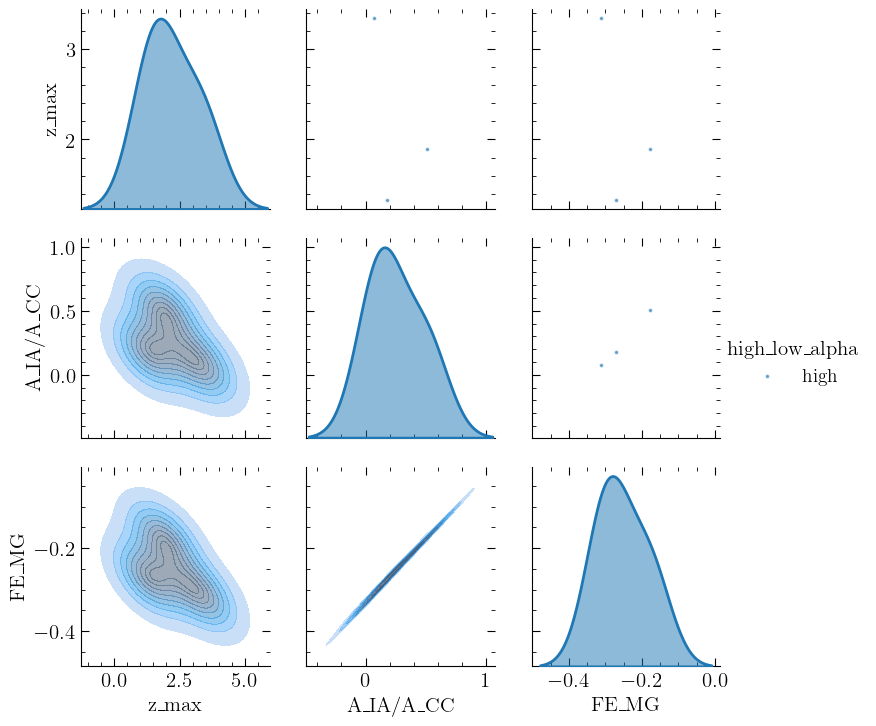

In [48]:
# Variables to plot
vars_to_plot = ['z_max', 'A_IA/A_CC', 'FE_MG']

# Create the PairGrid
g = sns.PairGrid(bin_test, vars=vars_to_plot, hue='high_low_alpha', diag_sharey=False)

# Lower triangle: 2D KDE
g.map_lower(sns.kdeplot, fill=True, alpha=0.5, common_norm=False)

# Upper triangle: scatter plot
g.map_upper(plt.scatter, s=10, alpha=0.7, edgecolor='white')

# Diagonal: 1D KDE
g.map_diag(sns.kdeplot, lw=2, fill=True, alpha=0.5, common_norm=False)

# Add legend
g.add_legend()

plt.show()


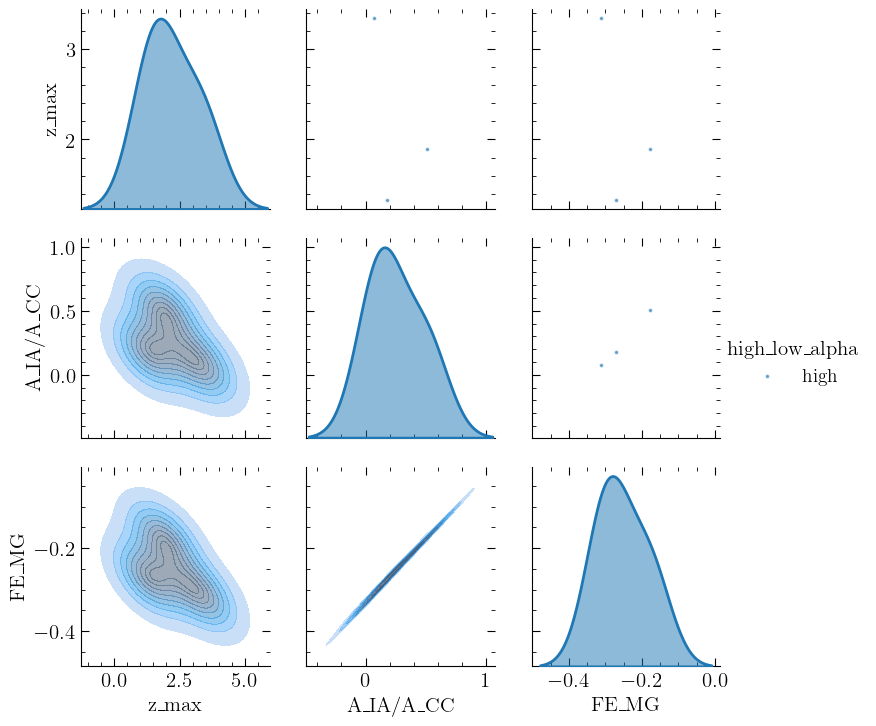

In [49]:
# Variables to plot
vars_to_plot = ['z_max', 'A_IA/A_CC', 'FE_MG']

# Create the PairGrid
g = sns.PairGrid(bin_test, vars=vars_to_plot, hue='high_low_alpha', diag_sharey=False)

# Lower triangle: 2D KDE
g.map_lower(sns.kdeplot, fill=True, alpha=0.5, common_norm=True)

# Upper triangle: scatter plot
g.map_upper(plt.scatter, s=10, alpha=0.7, edgecolor='white')

# Diagonal: 1D KDE
g.map_diag(sns.kdeplot, lw=2, fill=True, alpha=0.5, common_norm=True)

# Add legend
g.add_legend()

plt.show()


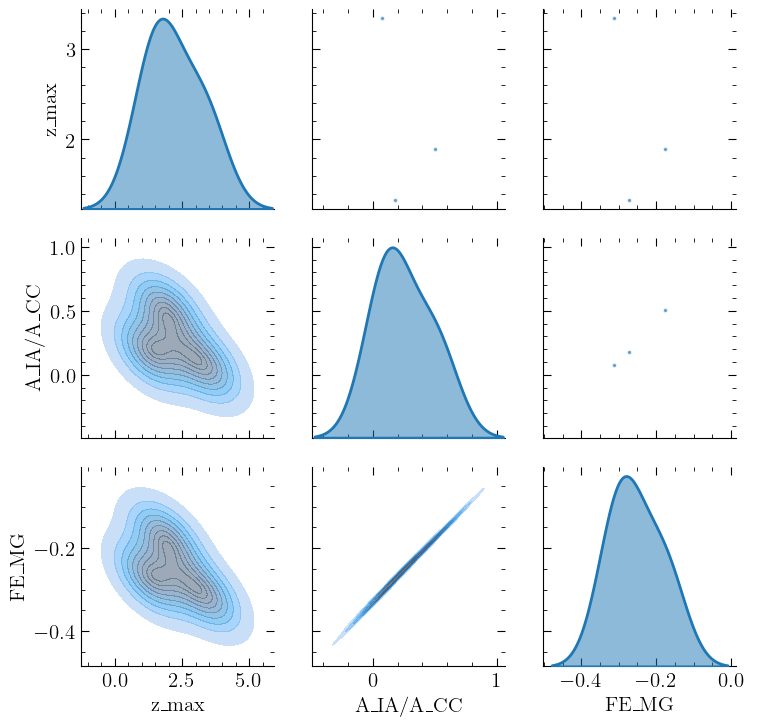

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables to plot
vars_to_plot = ['z_max', 'A_IA/A_CC', 'FE_MG']

# Create the PairGrid
g = sns.PairGrid(bin_test, vars=vars_to_plot, diag_sharey=False)

# Lower triangle: 2D KDE
g.map_lower(sns.kdeplot, fill=True, alpha=0.5)

# Upper triangle: scatter plot
g.map_upper(plt.scatter, s=10, alpha=0.7, edgecolor='white')

# Diagonal: 1D KDE
g.map_diag(sns.kdeplot, lw=2, fill=True, alpha=0.5)

# Add legend
g.add_legend()

plt.show()


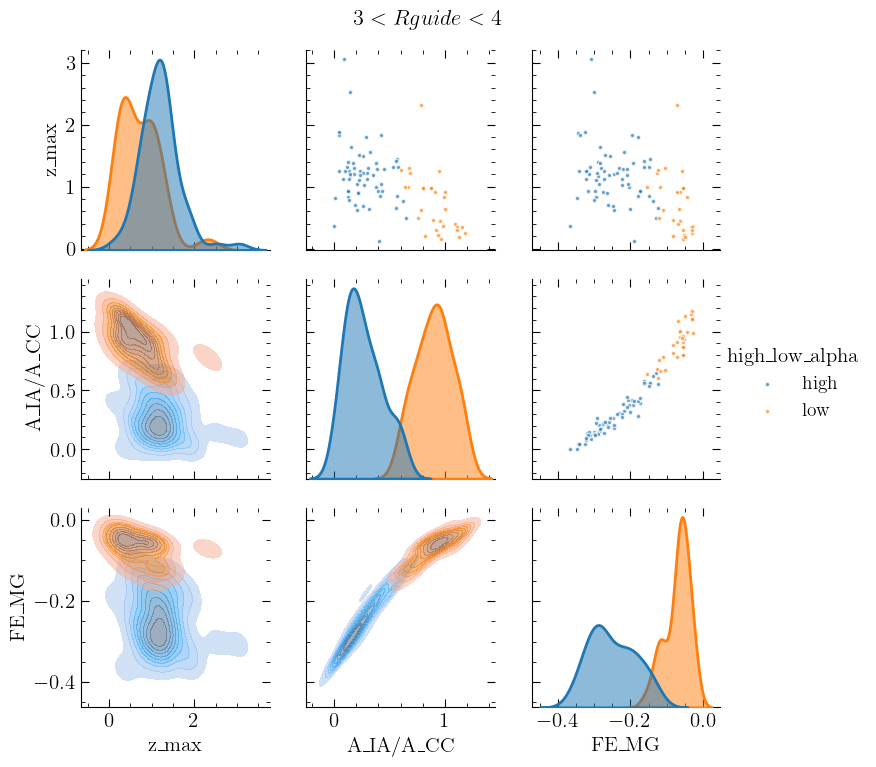

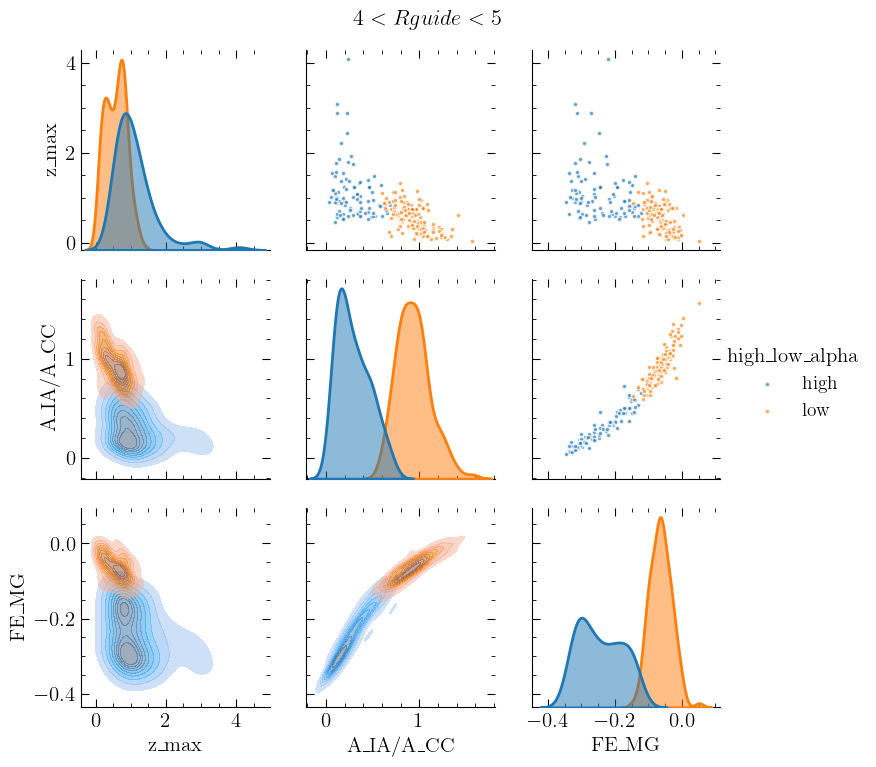

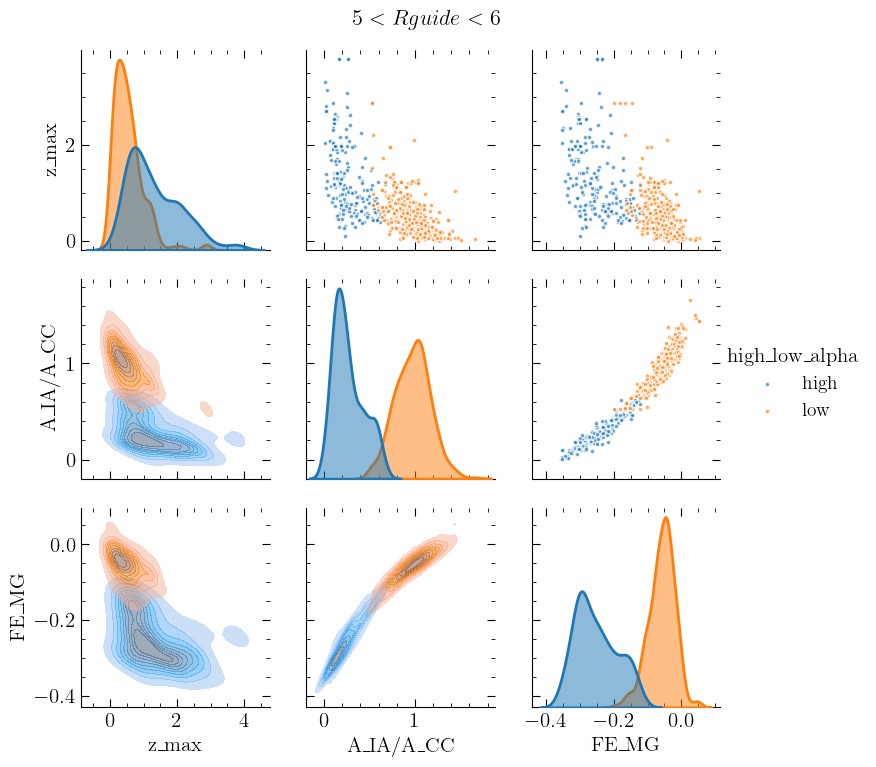

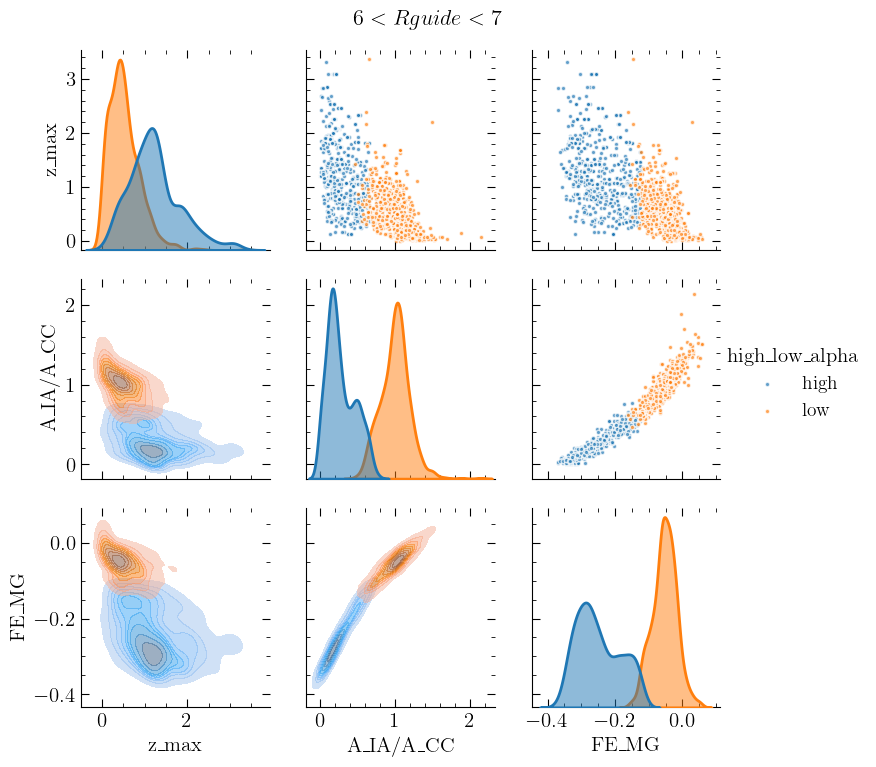

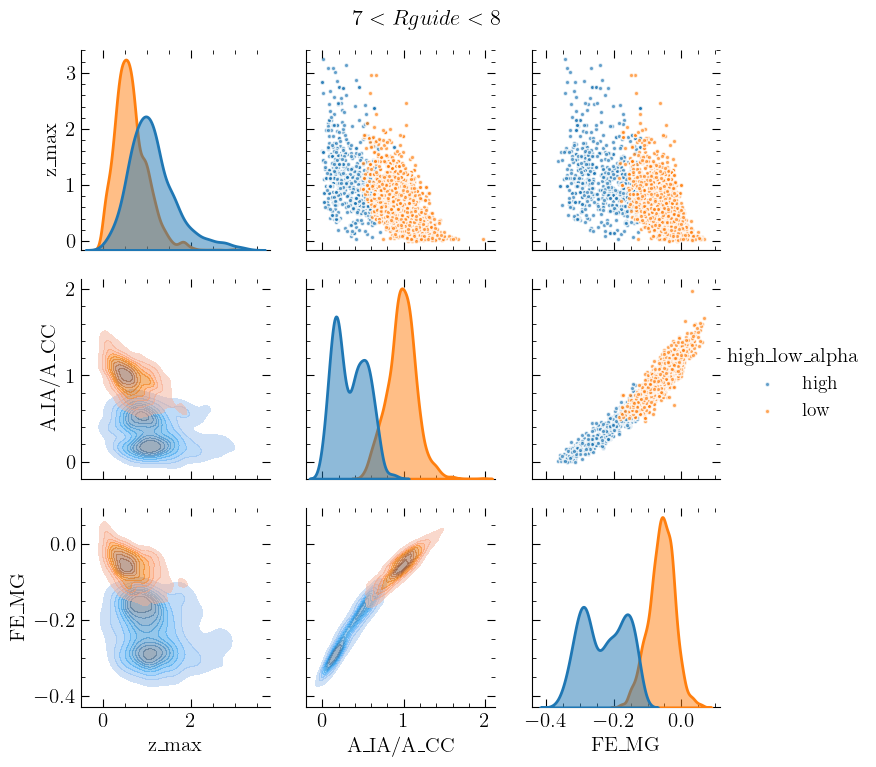

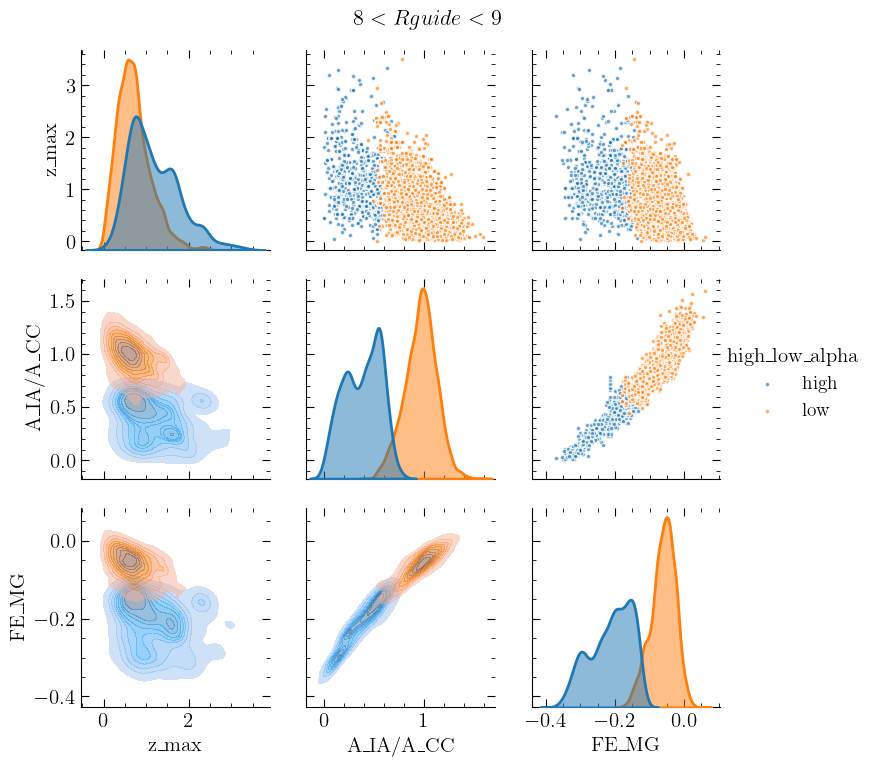

In [59]:
bins_to_plot = [3, 4, 5, 6, 7, 8]
vars_to_plot = ['z_max', 'A_IA/A_CC', 'FE_MG']

for bin_i in bins_to_plot:
    bin_test = circ_ones[circ_ones['R_guide_bin'] == bin_i]
    
    if bin_test.empty:
        continue  # skip empty bins
    
    g = sns.PairGrid(bin_test, vars=vars_to_plot, hue='high_low_alpha', diag_sharey=False)
    g.map_lower(sns.kdeplot, fill=True, alpha=0.5, common_norm=False)
    g.map_upper(plt.scatter, s=10, alpha=0.7, edgecolor='white')
    g.map_diag(sns.kdeplot, lw=2, fill=True, alpha=0.5, common_norm=False)
    g.add_legend()
    
    plt.suptitle(fr'${bin_i} < Rguide < {bin_i + 1}$', y=1.02, fontsize=16)
    g.savefig(f'pairgrid_R_guide_bin_{bin_i}.png', dpi=300, bbox_inches='tight')
    plt.show()


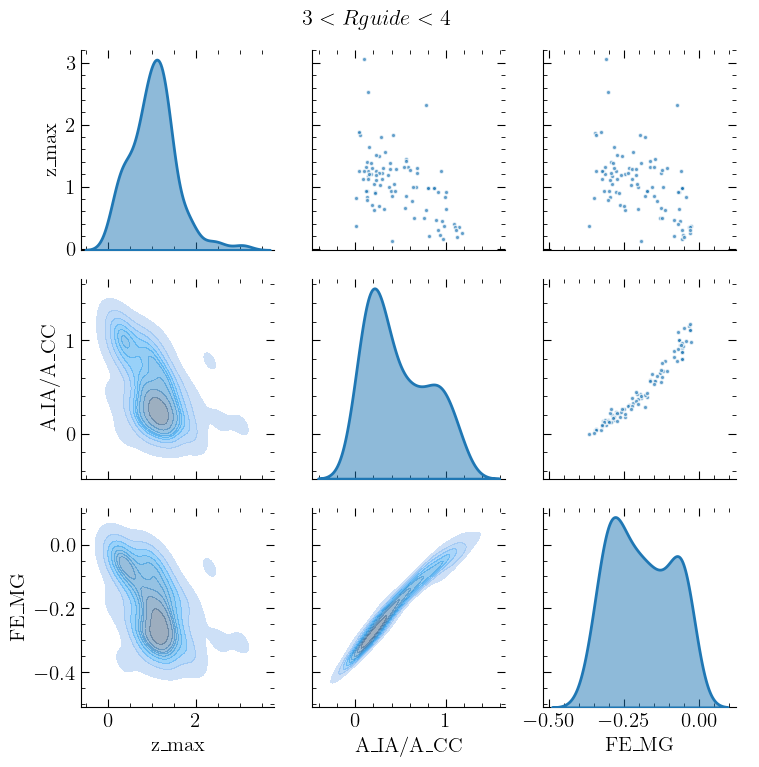

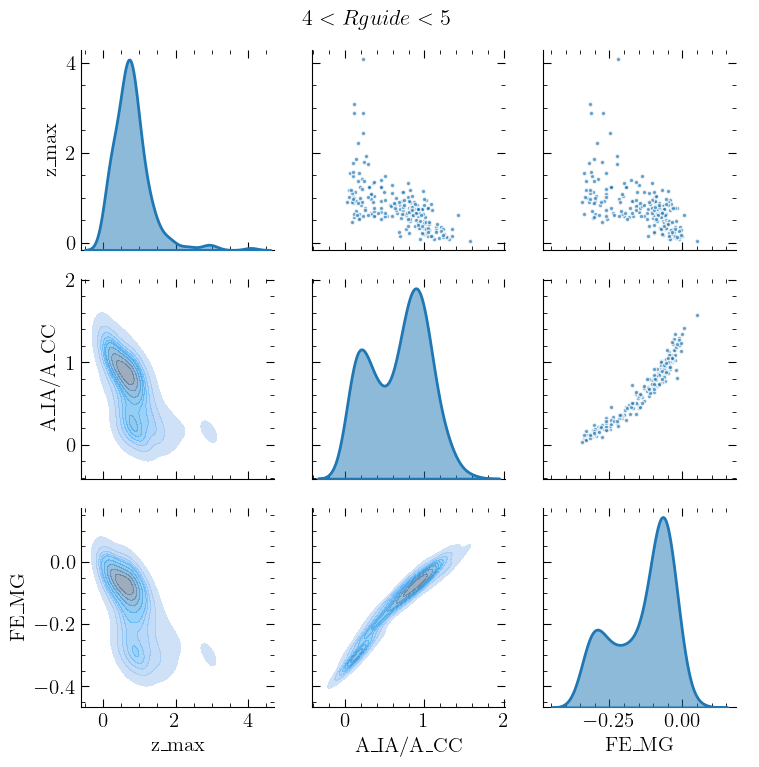

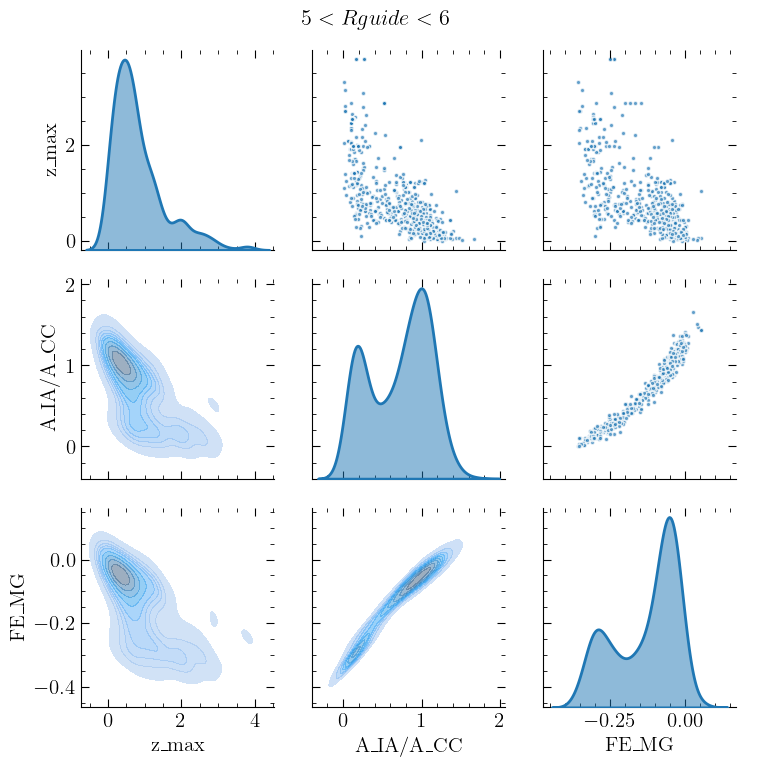

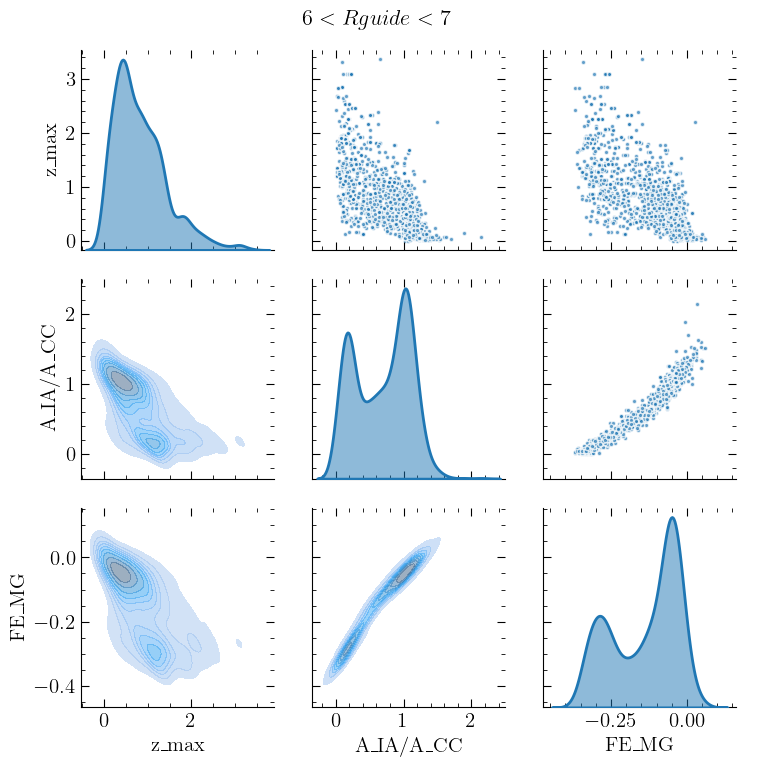

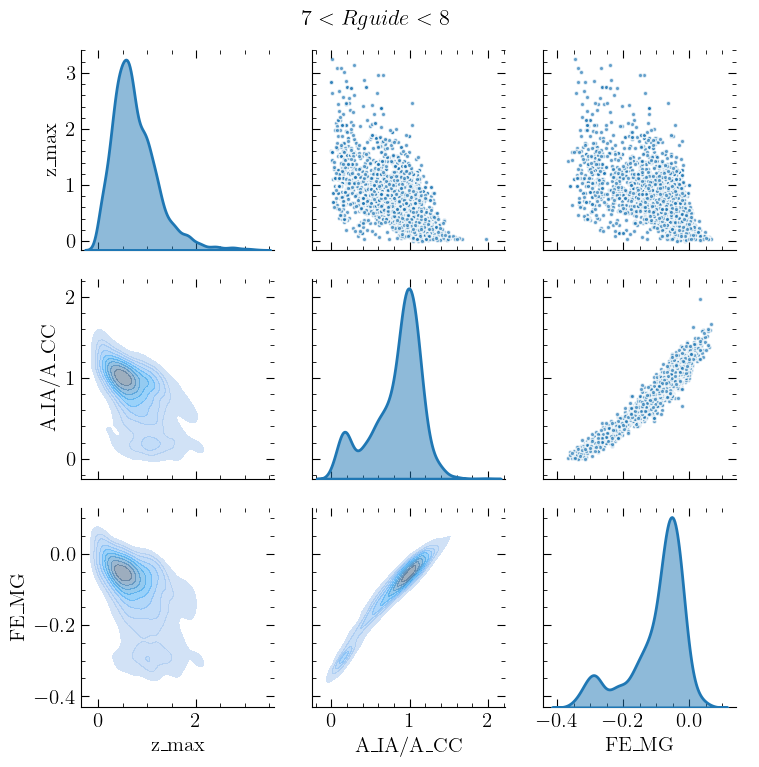

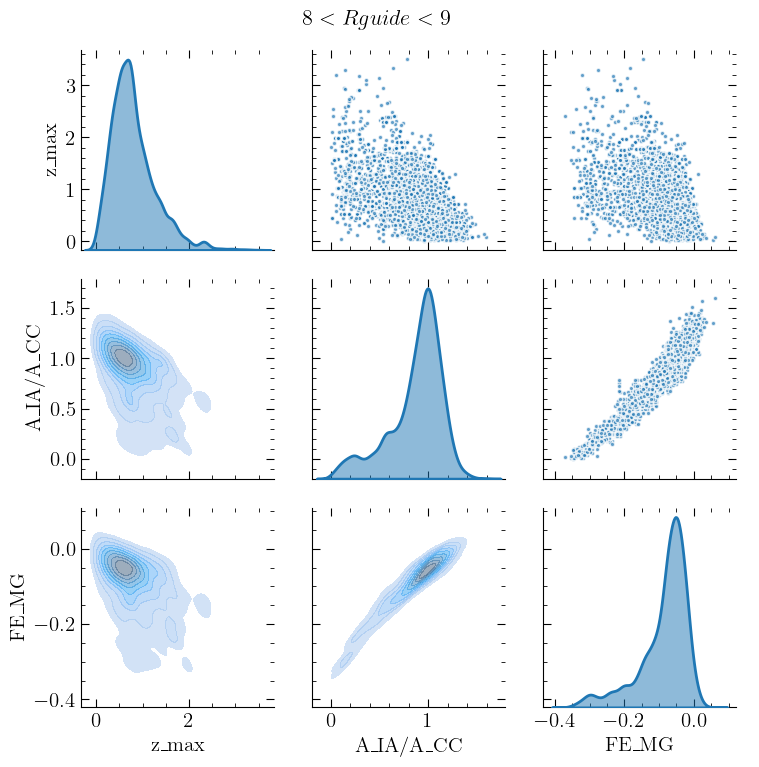

In [58]:
bins_to_plot = [3, 4, 5, 6, 7, 8]
vars_to_plot = ['z_max', 'A_IA/A_CC', 'FE_MG']

for bin_i in bins_to_plot:
    bin_test = circ_ones[circ_ones['R_guide_bin'] == bin_i]
    
    if bin_test.empty:
        continue  # skip empty bins
    
    g = sns.PairGrid(bin_test, vars=vars_to_plot, diag_sharey=False)
    g.map_lower(sns.kdeplot, fill=True, alpha=0.5, common_norm=False)
    g.map_upper(plt.scatter, s=10, alpha=0.7, edgecolor='white')
    g.map_diag(sns.kdeplot, lw=2, fill=True, alpha=0.5, common_norm=False)
    g.add_legend()
    
    plt.suptitle(fr'${bin_i} < Rguide < {bin_i + 1}$', y=1.02, fontsize=16)
    g.savefig(f'pairgrid_R_guide_bin_all_{bin_i}.png', dpi=300, bbox_inches='tight')
    plt.show()


In [71]:
max(bin_7['z_max'])

3.245314232114475

In [72]:
bin_7 = circ_ones[circ_ones['R_guide_bin'] == 7]
bin_edges_zmax = np.arange(0,4,0.1)
bin_7['z_max_bin'] = pd.cut(bin_7['z_max'], bins = bin_edges_zmax, right=False, labels=False)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_24883/593656747.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_7['z_max_bin'] = pd.cut(bin_7['z_max'], bins = bin_edges_zmax, right=False, labels=False)


/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_24883/2583157157.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_7['z_max_bin'] = pd.cut(bin_7['z_max'], bins = bin_edges_zmax, right=False, labels=False)


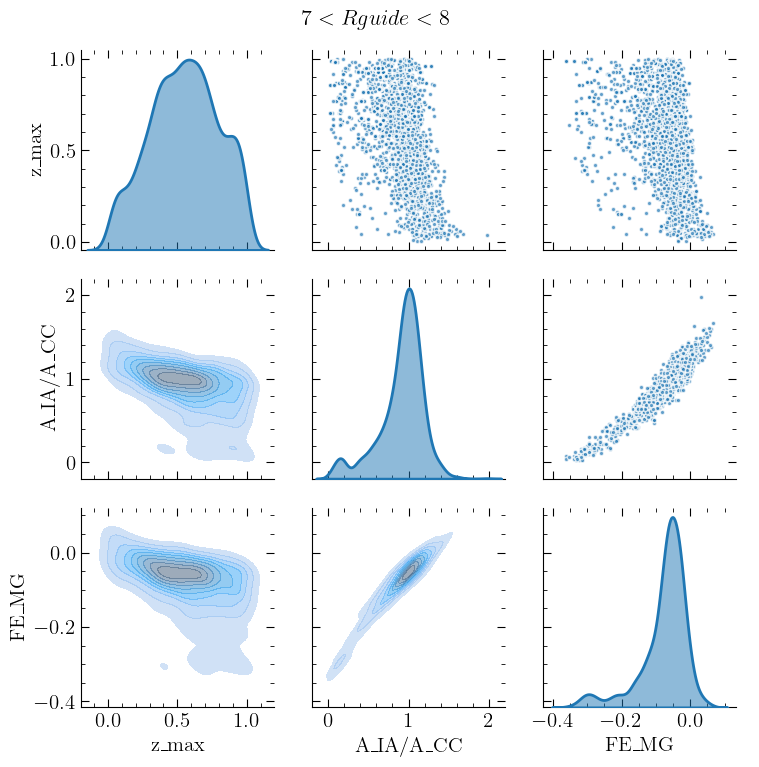

In [78]:
bin_7 = circ_ones[circ_ones['R_guide_bin'] == 7]
bin_edges_zmax = np.arange(0,4,1)
bin_7['z_max_bin'] = pd.cut(bin_7['z_max'], bins = bin_edges_zmax, right=False, labels=False)
bin_chosen = bin_7[bin_7['z_max_bin'] == 0]



g = sns.PairGrid(bin_chosen, vars=vars_to_plot, diag_sharey=False)
g.map_lower(sns.kdeplot, fill=True, alpha=0.5, common_norm=False)
g.map_upper(plt.scatter, s=10, alpha=0.7, edgecolor='white')
g.map_diag(sns.kdeplot, lw=2, fill=True, alpha=0.5, common_norm=False)
g.add_legend()
    
plt.suptitle(fr'$7 < Rguide < 8$', y=1.02, fontsize=16)
#g.savefig(f'pairgrid_R_guide_bin_all_{bin_i}.png', dpi=300, bbox_inches='tight')
plt.show()

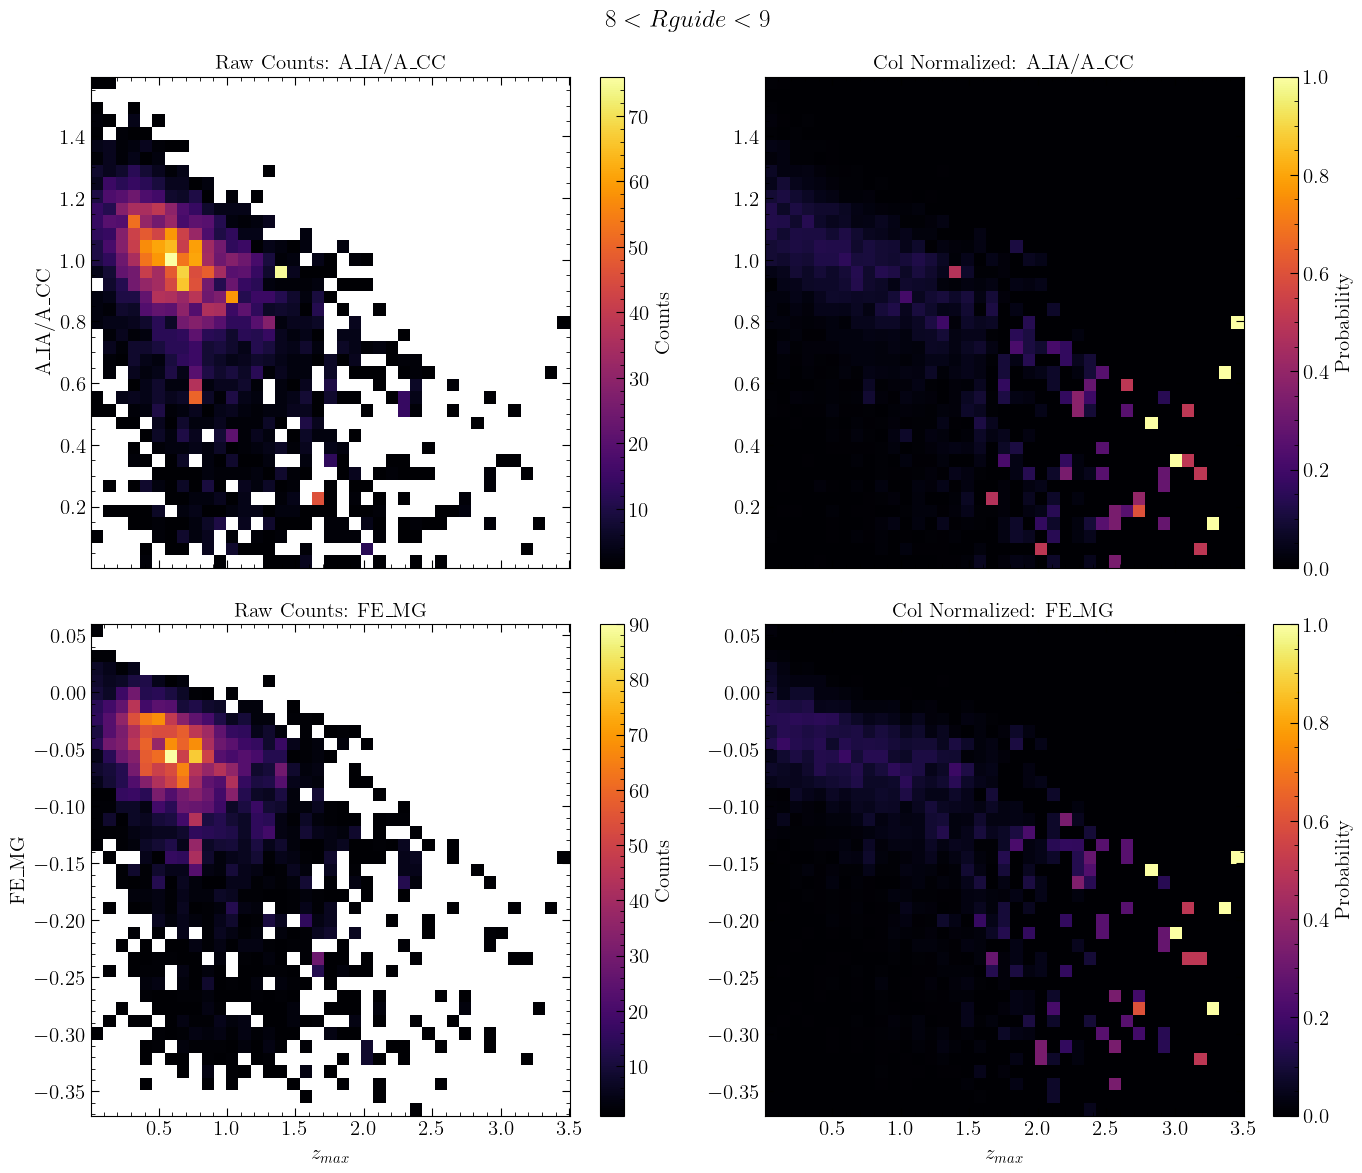

In [119]:
bin_8 = circ_ones[circ_ones['R_guide_bin'] == 8]

# Setup
n_bins = 40
x_data = bin_8['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_8['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_8['FE_MG'],     'label': 'FE_MG'}
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='inferno', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='inferno')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$8 < R guide < 9$")
plt.savefig('bin_8_2d.png', dpi=300)
plt.tight_layout()
plt.show()

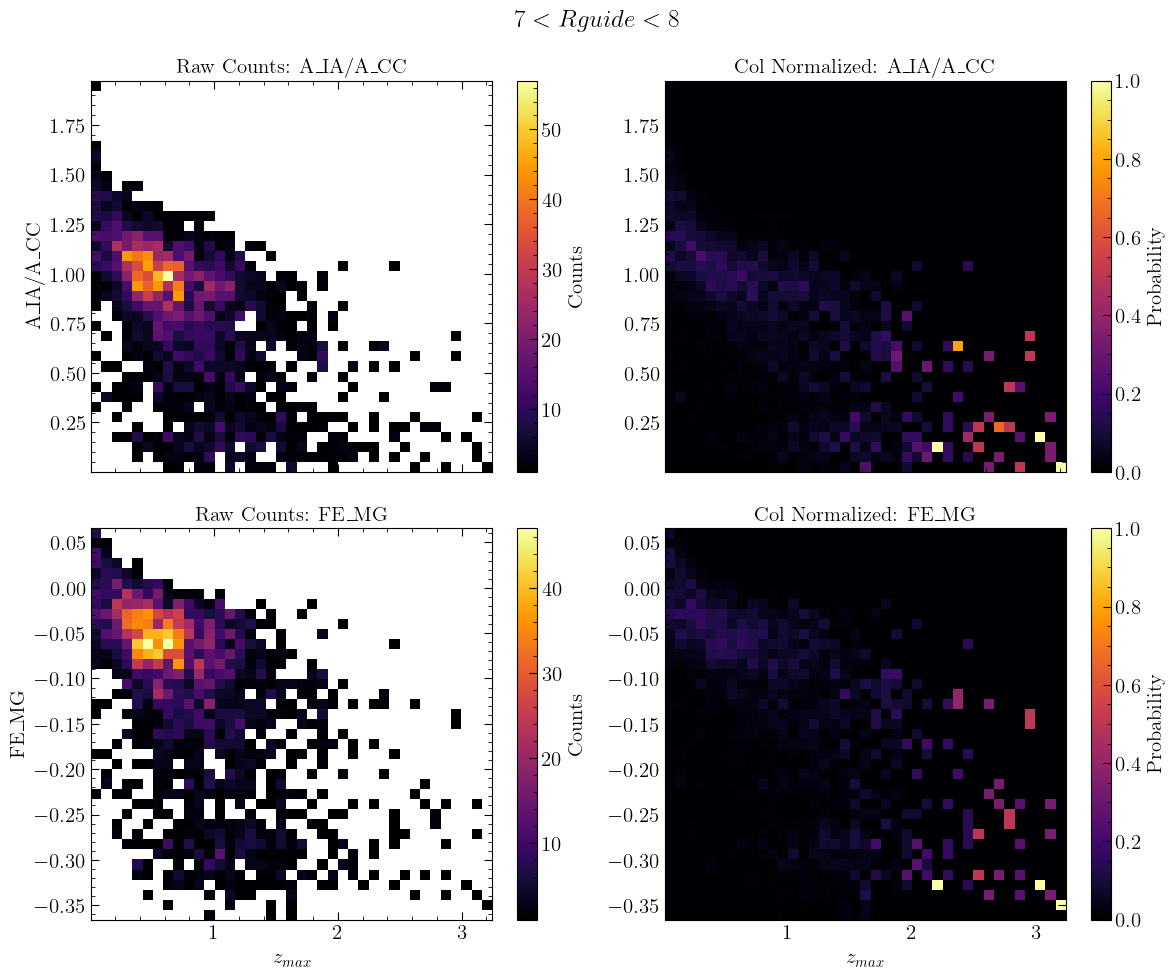

In [118]:
bin_7 = circ_ones[circ_ones['R_guide_bin'] == 7]

# Setup
n_bins = 40
x_data = bin_7['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_7['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_7['FE_MG'],     'label': 'FE_MG'}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='inferno', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='inferno')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$7 < R guide < 8$")
plt.tight_layout()
plt.savefig('bin_7_2d.png', dpi=300)
plt.show()

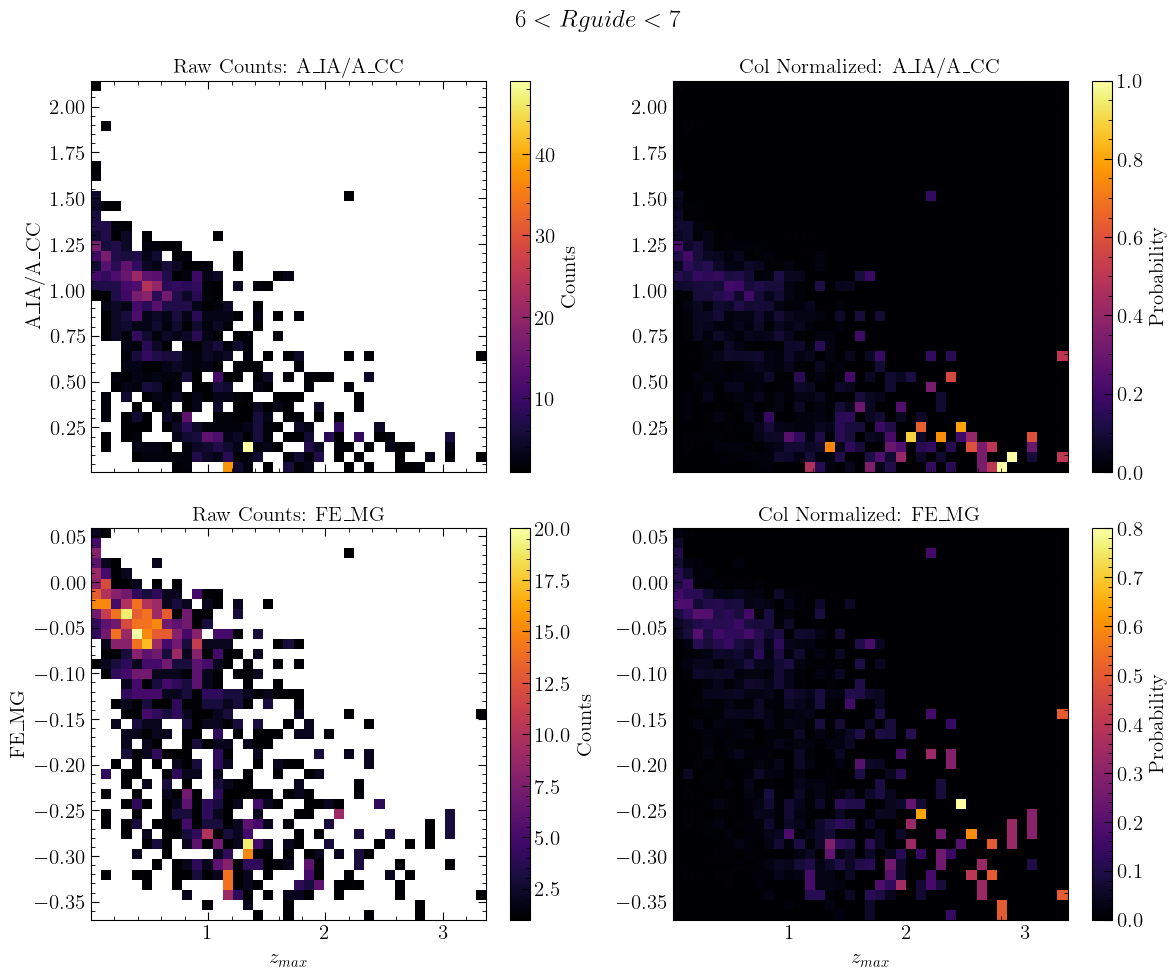

In [120]:
bin_6 = circ_ones[circ_ones['R_guide_bin'] == 6]

# Setup
n_bins = 40
x_data = bin_6['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_6['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_6['FE_MG'],     'label': 'FE_MG'}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='inferno', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='inferno')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$6 < R guide < 7$")
plt.tight_layout()
plt.savefig('bin_6_2d.png', dpi=300)
plt.show()

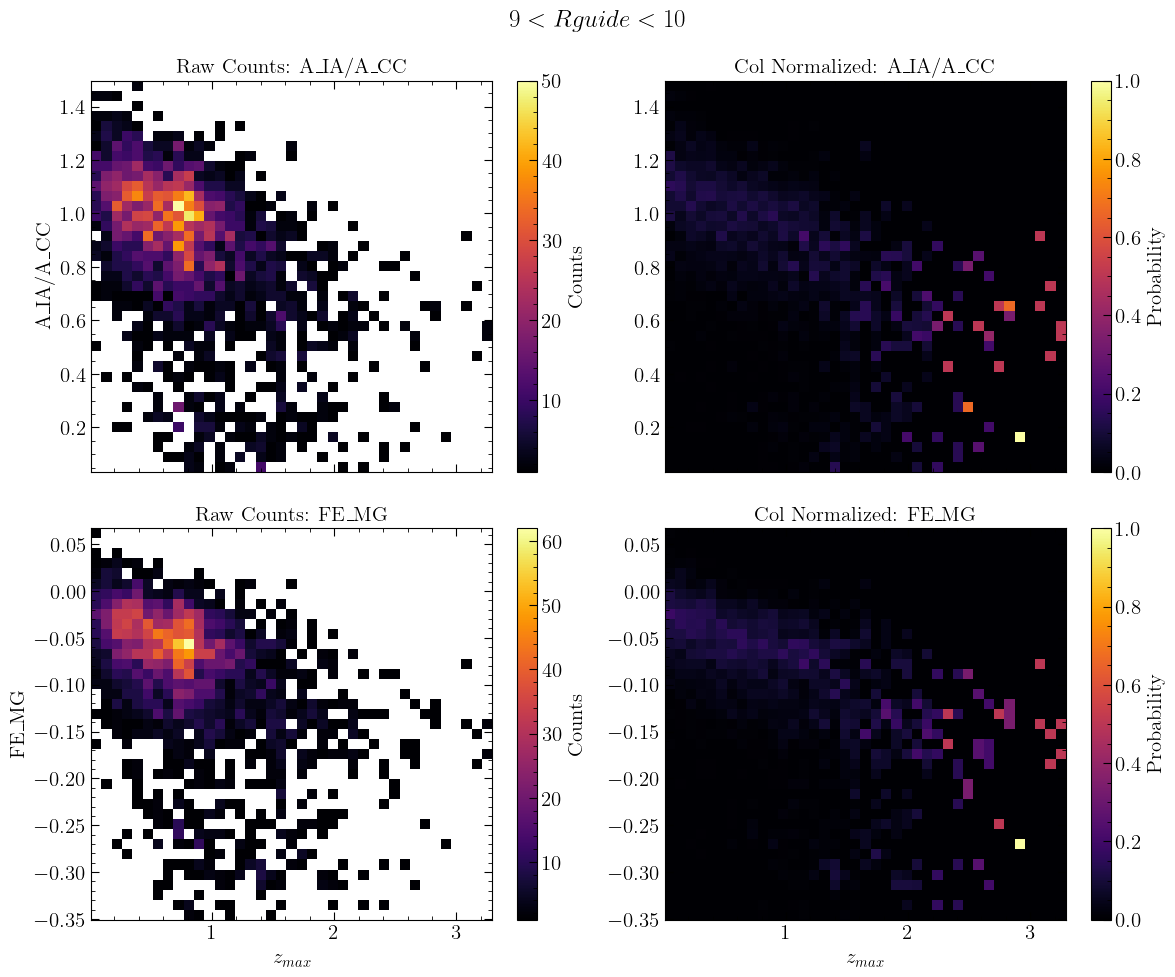

In [121]:
bin_9 = circ_ones[circ_ones['R_guide_bin'] == 9]

# Setup
n_bins = 40
x_data = bin_9['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_9['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_9['FE_MG'],     'label': 'FE_MG'}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='inferno', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='inferno')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$9 < R guide < 10$")
plt.tight_layout()
plt.savefig('bin_9_2d.png', dpi=300)
plt.show()

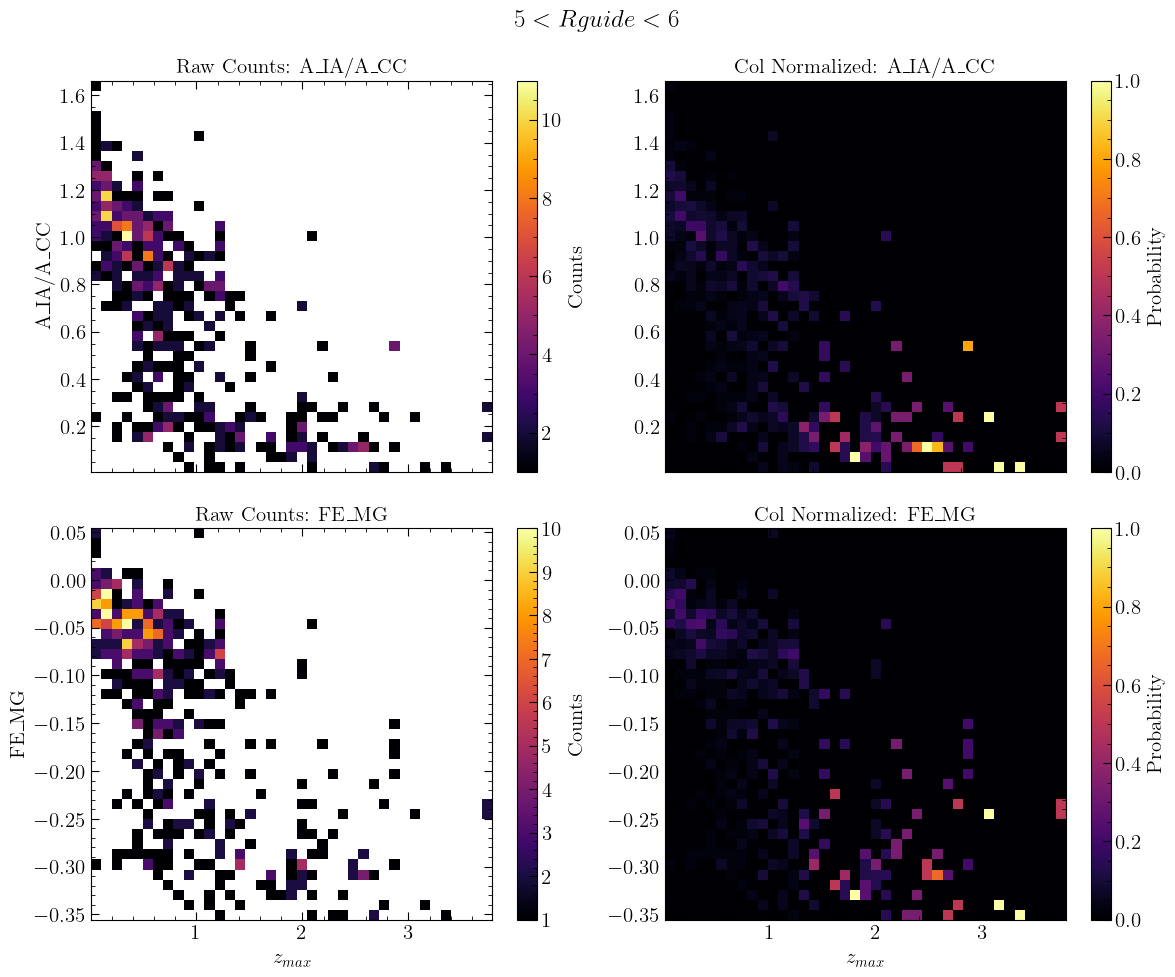

In [122]:
bin_5 = circ_ones[circ_ones['R_guide_bin'] == 5]

# Setup
n_bins = 40
x_data = bin_5['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_5['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_5['FE_MG'],     'label': 'FE_MG'}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='inferno', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='inferno')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$5 < R guide < 6$")
plt.tight_layout()
plt.savefig('bin_5_2d.png', dpi=300)
plt.show()

# Bin for Fe/H

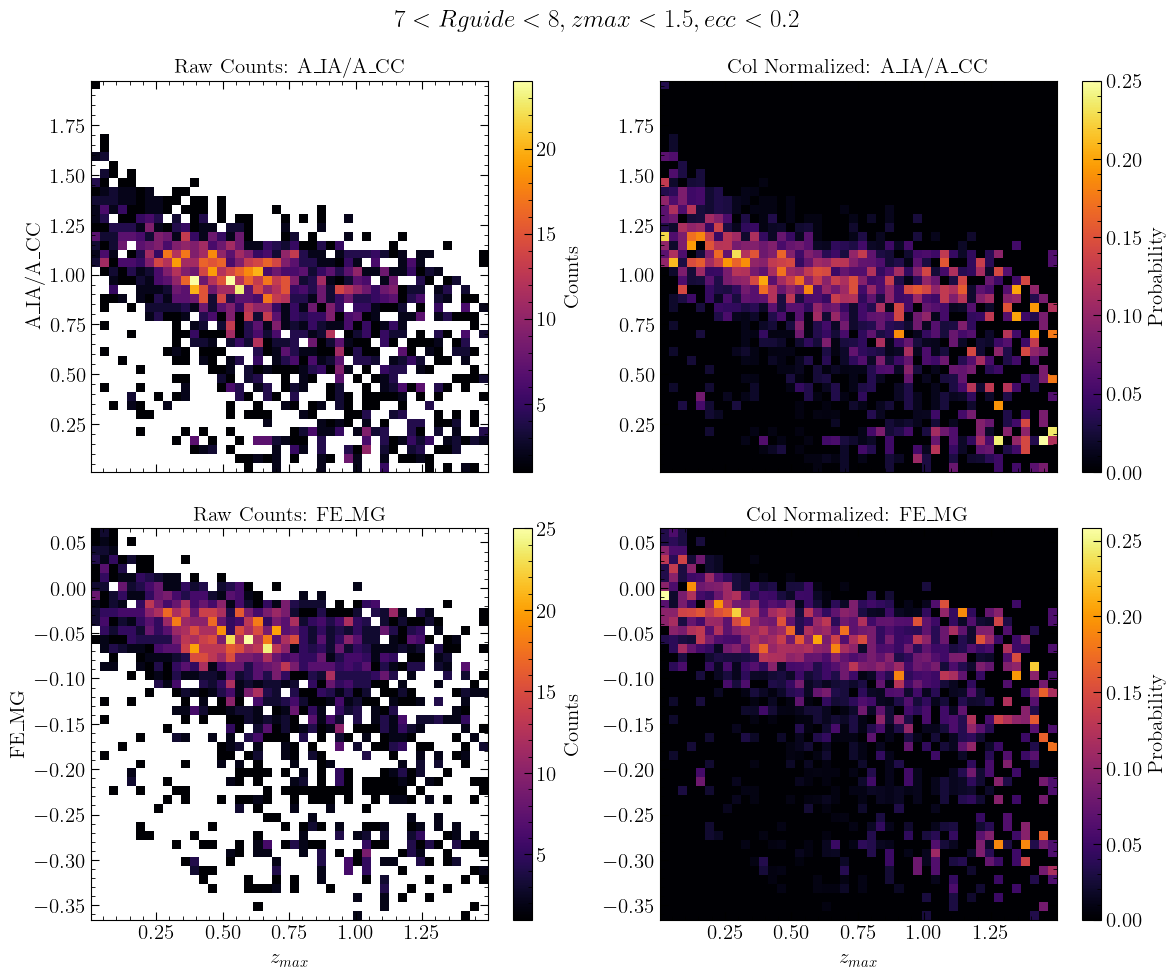

In [179]:
bin_7 = circ_ones[circ_ones['R_guide_bin'] == 7]
bin_temp = bin_7
#bin_temp = bin_7[(bin_7['FE_H'] < 0.2) & (bin_7['FE_H'] > 0.0)]
bin_temp = bin_temp[bin_temp['z_max'] < 1.5]

# Setup
n_bins = 45
x_data = bin_temp['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_temp['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_temp['FE_MG'],     'label': 'FE_MG'}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='inferno', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='inferno')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$7 < R guide < 8, zmax < 1.5, ecc < 0.2$")
plt.tight_layout()
plt.savefig('plots/bin_7_2d.png', dpi=300)
plt.show()

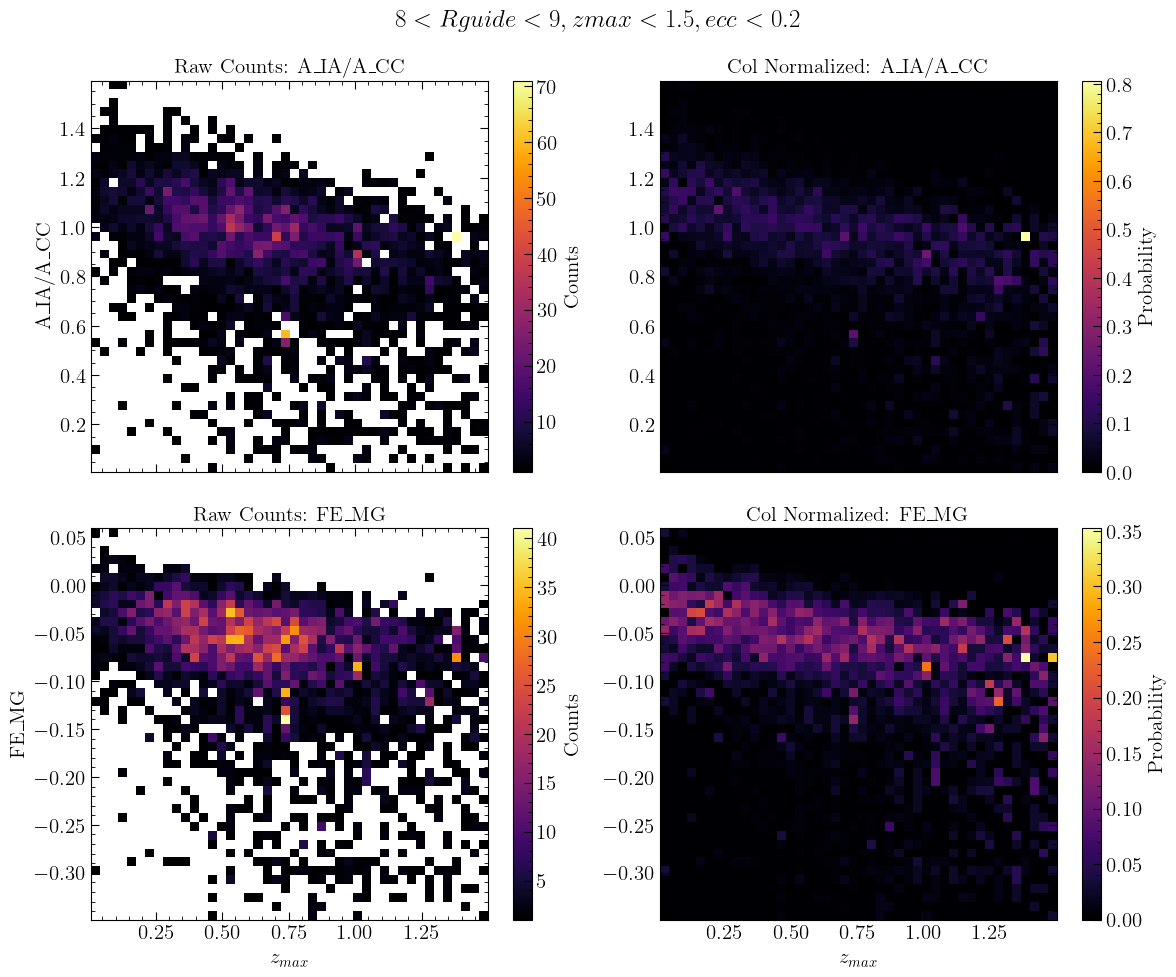

In [181]:
bin_8 = circ_ones[circ_ones['R_guide_bin'] == 8]
bin_temp = bin_8
#bin_temp = bin_7[(bin_7['FE_H'] < 0.2) & (bin_7['FE_H'] > 0.0)]
bin_temp = bin_temp[bin_temp['z_max'] < 1.5]

# Setup
n_bins = 45
x_data = bin_temp['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_temp['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_temp['FE_MG'],     'label': 'FE_MG'}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='inferno', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='inferno')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$8 < R guide < 9, zmax < 1.5, ecc < 0.2$")
plt.tight_layout()
plt.savefig('plots/bin_8_2d.png', dpi=300)
plt.show()

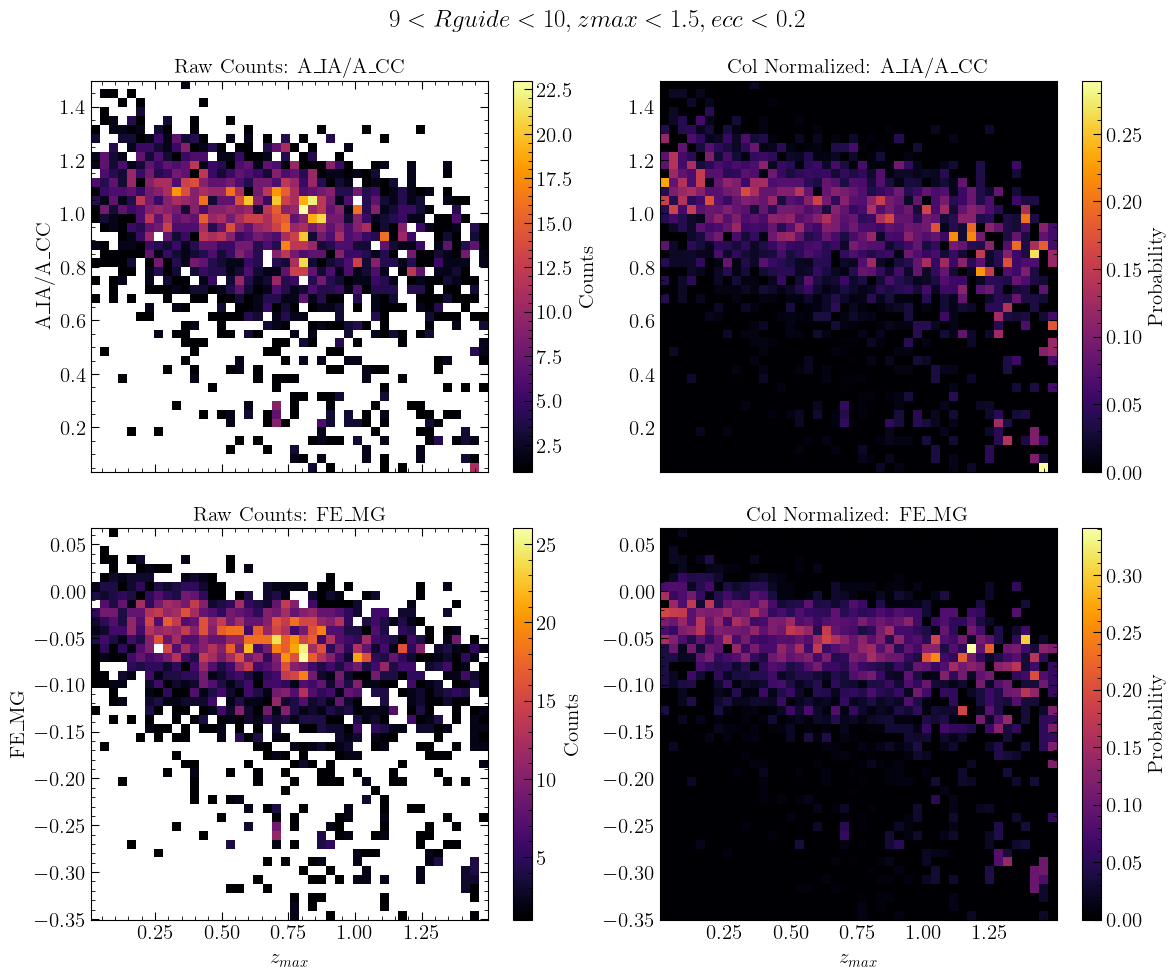

In [182]:
bin_9 = circ_ones[circ_ones['R_guide_bin'] == 9]
bin_temp = bin_9
#bin_temp = bin_7[(bin_7['FE_H'] < 0.2) & (bin_7['FE_H'] > 0.0)]
bin_temp = bin_temp[bin_temp['z_max'] < 1.5]

# Setup
n_bins = 45
x_data = bin_temp['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_temp['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_temp['FE_MG'],     'label': 'FE_MG'}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='inferno', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='inferno')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$9 < R guide < 10, zmax < 1.5, ecc < 0.2$")
plt.tight_layout()
plt.savefig('plots/bin_9_2d.png', dpi=300)
plt.show()

# Binned Z_Max and A_IA/A_CC histograms

In [128]:
zmax_bin_edges = np.arange(0, 4, 0.5)  # 0,1,2,...,10


circ_ones['z_max_bin'] = pd.cut(circ_ones['z_max'], bins=zmax_bin_edges, right=False, labels=False)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_24883/1661543751.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  circ_ones['z_max_bin'] = pd.cut(circ_ones['z_max'], bins=zmax_bin_edges, right=False, labels=False)


In [140]:
circ_ones['z_max_bin']

0        0.0
1        3.0
3        1.0
4        1.0
5        1.0
        ... 
29095    0.0
29096    0.0
29097    3.0
29098    0.0
29099    0.0
Name: z_max_bin, Length: 19952, dtype: float64

In [145]:
bin_test = circ_ones[circ_ones['z_max_bin'] == 0]
bin_test['z_max']

0        0.376810
30       0.327166
39       0.353497
40       0.353497
41       0.353497
           ...   
29094    0.094572
29095    0.217253
29096    0.217253
29098    0.257361
29099    0.257361
Name: z_max, Length: 5895, dtype: float64

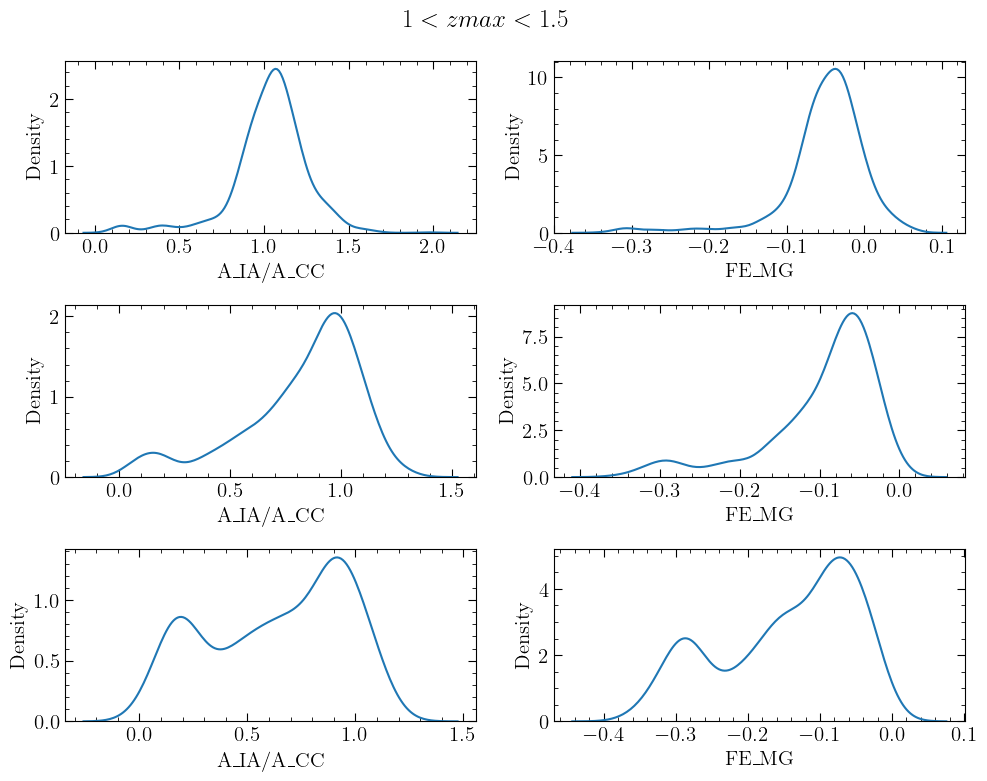

In [153]:
bin_to_plot = 7
gal_bin = circ_ones[circ_ones['R_guide_bin'] == bin_to_plot]
vars_to_plot = ['z_max', 'A_IA/A_CC', 'FE_MG']
z_max_bins_to_plot = [0, 1, 2]
plt.figure(figsize=(10,8))
i = 1

for bin_i in z_max_bins_to_plot:
    bin_test = gal_bin[gal_bin['z_max_bin'] == bin_i]
    plt.subplot(3,2,i)
    #plt.hist(bin_test['A_IA/A_CC'])
    sns.kdeplot(bin_test['A_IA/A_CC'])

    plt.subplot(3,2,i+1)
    #plt.hist(bin_test['FE_MG'])
    sns.kdeplot(bin_test['FE_MG'])
    i += 2
    if bin_i == 0:
        plt.suptitle(r'$0 < zmax < 0.5$')
    if bin_i == 1:
        plt.suptitle(r'$0.5 < zmax < 1$')
    if bin_i == 2:
        plt.suptitle(r'$1 < zmax < 1.5$')


plt.tight_layout()

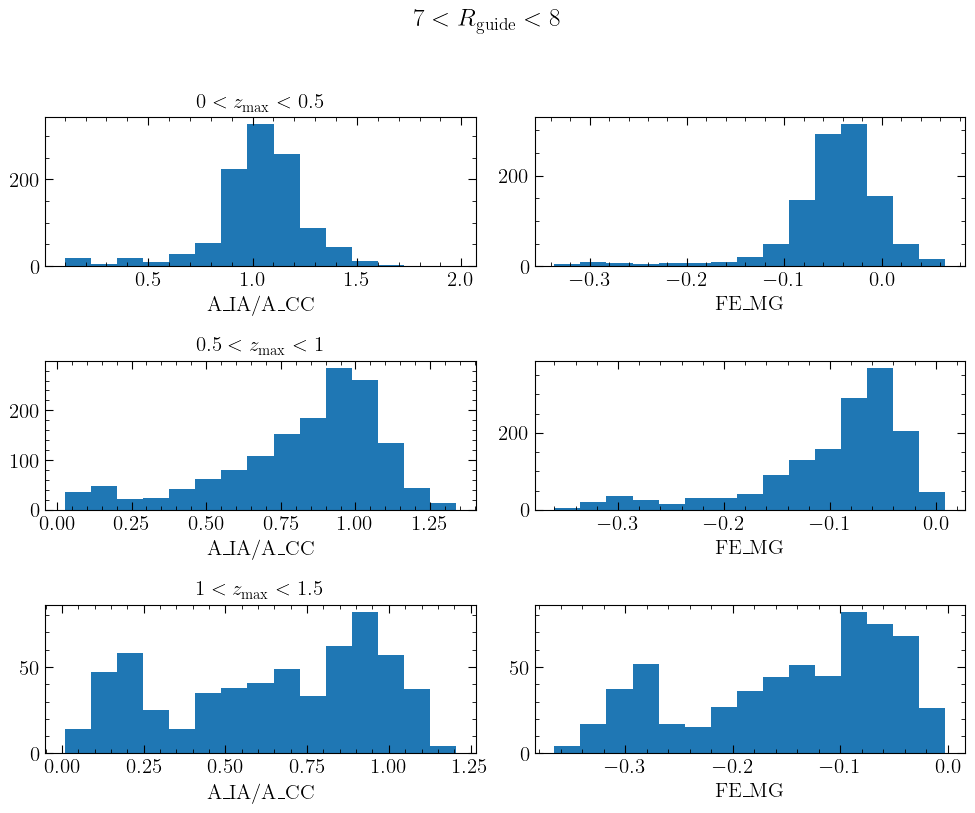

In [186]:
bin_to_plot = 7
gal_bin = circ_ones[circ_ones['R_guide_bin'] == bin_to_plot]

z_max_bins_to_plot = [0, 1, 2]
zmax_labels = [
    r'$0 < z_{\max} < 0.5$',
    r'$0.5 < z_{\max} < 1$',
    r'$1 < z_{\max} < 1.5$'
]

plt.figure(figsize=(10,8))

i = 1
for bin_i, zlabel in zip(z_max_bins_to_plot, zmax_labels):

    bin_test = gal_bin[gal_bin['z_max_bin'] == bin_i]

    # --- Left column: A_IA/A_CC ---
    plt.subplot(3, 2, i)
    plt.hist(bin_test['A_IA/A_CC'], bins=15)
    plt.xlabel('A_IA/A_CC')
    plt.title(zlabel)
    
    # --- Right column: FE_MG ---
    plt.subplot(3, 2, i + 1)
    plt.hist(bin_test['FE_MG'], bins=15)
    plt.xlabel('FE_MG')
    
    i += 2

plt.suptitle(rf'${bin_to_plot} < R_{{\rm guide}} < {bin_to_plot + 1}$', y=1.02)
plt.tight_layout()
plt.savefig("plots/histograms_of_zmax_bins.png", dpi=300)
plt.show()

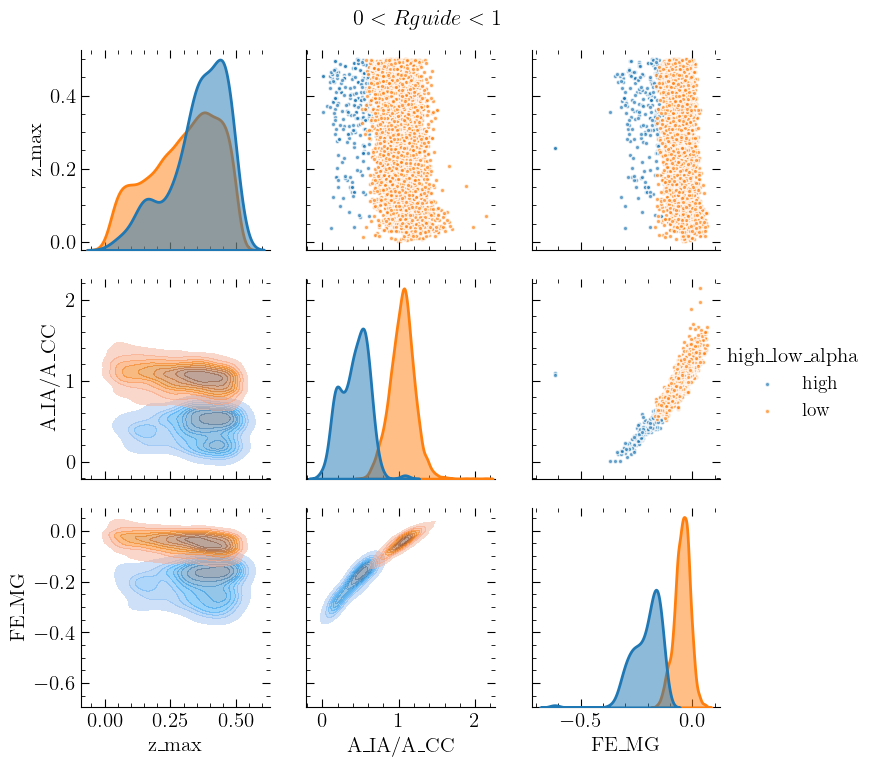

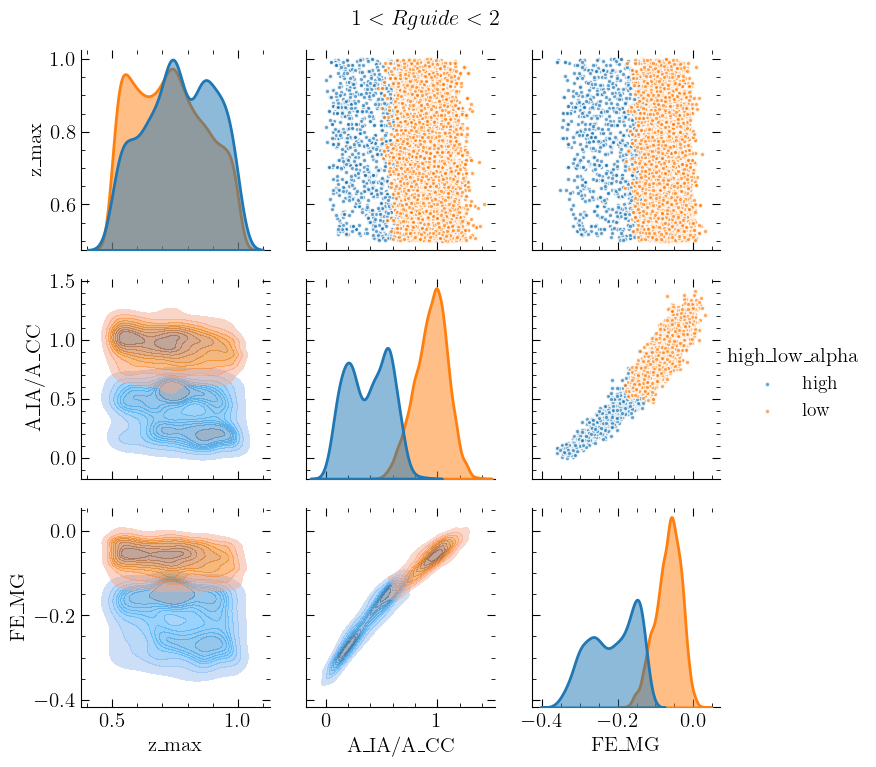

In [130]:
bins_to_plot = [7]
vars_to_plot = ['z_max', 'A_IA/A_CC', 'FE_MG']
z_max_bins_to_plot = [0, 0.5, 1]

for bin_i in z_max_bins_to_plot:
    bin_test = circ_ones[circ_ones['z_max_bin'] == bin_i]
    
    if bin_test.empty:
        continue  # skip empty bins
    
    g = sns.PairGrid(bin_test, vars=vars_to_plot, hue='high_low_alpha', diag_sharey=False)
    g.map_lower(sns.kdeplot, fill=True, alpha=0.5, common_norm=False)
    g.map_upper(plt.scatter, s=10, alpha=0.7, edgecolor='white')
    g.map_diag(sns.kdeplot, lw=2, fill=True, alpha=0.5, common_norm=False)
    g.add_legend()
    
    plt.suptitle(fr'${bin_i} < Rguide < {bin_i + 1}$', y=1.02, fontsize=16)
    g.savefig(f'pairgrid_R_guide_bin_{bin_i}.png', dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

from matplotlib.pyplot import figure
from astropy.io import fits
from astropy.table import Table

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import QTable

filename_path = 'files/astraMWMLite-0.6.0.fits'

# this function is Lucy's way to get rid of columns that are more than 1D (pandas doesn't support that)
def Table_to_pandas(fn):
    data = fits.open(fn)
    df = QTable(data[1].data)
    cols = []
    cols_drop = []
    for i in df.columns:
        if np.size(df[i][0])==1:
            cols.append(i)
        else:
            cols_drop.append(i)
    print(cols_drop)
    return df[cols].to_pandas()

df_sdss5 = Table_to_pandas(filename_path)

df_sdss5 = df_sdss5[(df_sdss5['teff']>4500) & (df_sdss5['teff']<6500)]
df_sdss5 = df_sdss5[(df_sdss5['snr']>=200)]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

from matplotlib.pyplot import figure
from astropy.io import fits
from astropy.table import Table

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import QTable

filename_path = 'files/astraMWMLite-0.6.0.fits'

# this function is Lucy's way to get rid of columns that are more than 1D (pandas doesn't support that)
def Table_to_pandas(fn):
    data = fits.open(fn)
    df = QTable(data[1].data)
    cols = []
    cols_drop = []
    for i in df.columns:
        if np.size(df[i][0])==1:
            cols.append(i)
        else:
            cols_drop.append(i)
    print(cols_drop)
    return df[cols].to_pandas()

df_sdss5 = Table_to_pandas(filename_path)

df_sdss5 = df_sdss5[(df_sdss5['teff']>4500) & (df_sdss5['teff']<6500)]
df_sdss5 = df_sdss5[(df_sdss5['snr']>=200)]

In [ ]:
df_exo_sdss = df_exo_sdss.loc[df_exo_sdss['e_fe_h']<0.1].reset_index(drop=True)